# 01 — Expression Valence

Measures positive vs negative facial expression over time, from two complementary signals:

1. **Emotion probabilities** (`pf_happiness` ... `pf_neutral`) — Py-Feat's 7-class classifier output.
2. **Action-Unit intensities** — AU12 (lip-corner pull, i.e. smile) and an anger composite of AU04 (brow lower) + AU05 (upper-lid raise) + AU07 (lid tighten).

**Outputs:**
- Summary table of total seconds per dominant emotion.
- Stacked-area timeline of emotion probabilities.
- Time series of AU12 (smile) and anger composite.
- Per-frame `valence = AU12 - anger_composite` column saved to a new parquet for reuse by later notebooks.

**Input:** `data/<video>_merged.parquet` produced by `00_pipeline.ipynb`.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

Set `VIDEO_STEM` to the stem (filename without extension) of the video you processed with `00_pipeline.ipynb`. For example, if your video is `sample.mp4`, the stem is `sample` — the notebook will then load `data/sample_merged.parquet` and write `data/sample_valence.parquet`.

Nothing else in this notebook needs editing for a new video.


In [11]:
VIDEO_STEM = "sample"  # <-- matches the stem used in 00_pipeline.ipynb

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PARQUET_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.parquet"
META_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.meta.json"
VALENCE_OUT = DATA_DIR / f"{VIDEO_STEM}_valence.parquet"

print("Input :", PARQUET_PATH)
print("Output:", VALENCE_OUT)

Input : /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_merged.parquet
Output: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_valence.parquet


In [12]:
df = pd.read_parquet(PARQUET_PATH)
meta = pd.read_json(META_PATH, typ="series")
FPS = float(meta["effective_fps"])  # frames-per-second of the sampled series
print(f"{len(df)} sampled frames, effective fps = {FPS:.2f}")
df.head(3)

165 sampled frames, effective fps = 6.00


,frame,pf_FaceRectX,pf_FaceRectY,pf_FaceRectWidth,pf_FaceRectHeight,pf_FaceScore,pf_x_0,pf_x_1,pf_x_2,pf_x_3,pf_x_4,pf_x_5,pf_x_6,pf_x_7,pf_x_8,pf_x_9,pf_x_10,pf_x_11,pf_x_12,pf_x_13,pf_x_14,pf_x_15,pf_x_16,pf_x_17,pf_x_18,...,mp_pose_l_elbow_x,mp_pose_l_elbow_y,mp_pose_l_elbow_z,mp_pose_l_elbow_v,mp_pose_r_elbow_x,mp_pose_r_elbow_y,mp_pose_r_elbow_z,mp_pose_r_elbow_v,mp_pose_l_wrist_x,mp_pose_l_wrist_y,mp_pose_l_wrist_z,mp_pose_l_wrist_v,mp_pose_r_wrist_x,mp_pose_r_wrist_y,mp_pose_r_wrist_z,mp_pose_r_wrist_v,mp_pose_l_hip_x,mp_pose_l_hip_y,mp_pose_l_hip_z,mp_pose_l_hip_v,mp_pose_r_hip_x,mp_pose_r_hip_y,mp_pose_r_hip_z,mp_pose_r_hip_v,timestamp
0,0,519.918694,272.933362,227.425503,281.001893,0.999181,520.523042,523.675914,529.473977,537.559496,548.567274,564.548551,585.259794,609.547189,638.061438,666.781347,691.382727,712.055732,728.102691,738.138415,744.704459,749.427722,751.621890,538.583320,554.554834,...,0.788142,1.078022,-0.256202,0.284957,0.195515,1.240849,-0.312661,0.182088,0.826058,1.551448,-0.424262,0.094261,0.203969,1.569180,-0.680746,0.055634,0.617857,1.597938,-0.026680,0.000262,0.383883,1.642882,0.031453,0.000211,0.000000
1,5,524.518676,274.493958,229.274511,278.821156,0.999232,525.741125,529.029156,534.920038,542.973800,553.899636,569.651581,590.099177,614.189544,642.442699,670.922615,695.329245,715.888461,731.949390,742.251125,749.123409,754.079504,756.550562,543.382180,559.387747,...,0.788900,1.072062,-0.274050,0.285622,0.177528,1.237659,-0.382536,0.200346,0.838439,1.560048,-0.490155,0.089535,0.155611,1.569308,-0.717756,0.054093,0.617698,1.631448,-0.027086,0.000271,0.383881,1.648865,0.031783,0.000213,0.166667
2,10,524.179340,272.163873,233.032264,283.197949,0.999275,530.382916,532.495140,537.666197,545.400268,555.938200,571.302844,591.388621,615.529101,644.033582,672.916910,697.468919,718.119562,734.515008,745.391918,752.882629,757.968884,760.156075,546.836208,562.824010,...,0.794182,1.202609,-0.234528,0.281576,0.175390,1.247655,-0.377758,0.213823,0.838154,1.579179,-0.486390,0.085271,0.159465,1.584551,-0.711673,0.052361,0.619557,1.653885,-0.019115,0.000287,0.385019,1.665081,0.023625,0.000223,0.333333


## 1. Emotion probabilities — dominant emotion per frame

**What this section does:** converts Py-Feat's 7-way emotion probability outputs into a single "dominant emotion" label per frame, then reports how many seconds the subject spent in each dominant state.

**How it works:**
1. For each frame, Py-Feat assigns a probability to each of 7 emotions (anger, disgust, fear, happiness, sadness, surprise, neutral). The 7 probabilities sum to ~1.
2. We take `argmax` across those 7 columns to pick the single most-likely emotion per frame.
3. We count frames per dominant label and multiply by `frame_duration_s = 1/effective_fps` to convert counts into seconds. Pct is share of total detected frames.

**Why dominant emotion (and not, say, mean probability):** a mean would dilute peaks — a 1-second genuine smile would look small if the rest of the video is neutral. Dominant-emotion counting gives you "time spent in each state", which maps cleanly to phrases like "the subject was visibly happy for 4 seconds."

**Caveats:** the classifier is conservative — it tends to label subtle expressions as `neutral`. That's why Section 3 also computes the continuous AU-based view.


In [13]:
EMOTION_COLS = ["pf_anger", "pf_disgust", "pf_fear", "pf_happiness", "pf_sadness", "pf_surprise", "pf_neutral"]
emo = df[["frame", "timestamp"] + EMOTION_COLS].dropna(subset=EMOTION_COLS).copy()
emo["dominant"] = emo[EMOTION_COLS].idxmax(axis=1).str.replace("pf_", "", regex=False)

# Each sampled frame represents 1/FPS seconds of real time.
frame_duration_s = 1.0 / FPS
summary = (
    emo["dominant"].value_counts().rename("n_frames").to_frame()
    .assign(seconds=lambda s: s["n_frames"] * frame_duration_s)
    .assign(pct=lambda s: 100 * s["n_frames"] / s["n_frames"].sum())
    .round({"seconds": 2, "pct": 1})
)
summary

,n_frames,seconds,pct
dominant,,,
neutral,73,12.17,44.2
disgust,58,9.67,35.2
happiness,24,4.00,14.5
sadness,10,1.67,6.1


## 2. Stacked-area emotion timeline

Shows how the emotion mix evolves over the video.

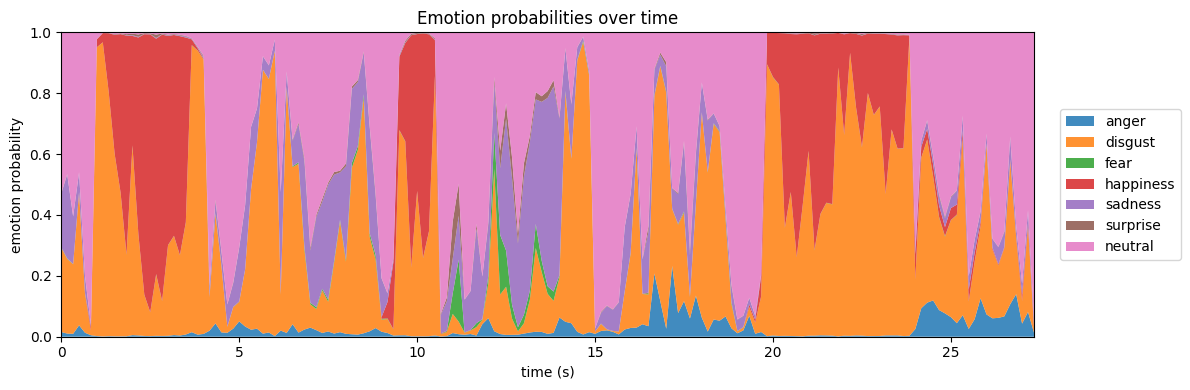

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
labels = [c.replace("pf_", "") for c in EMOTION_COLS]
ax.stackplot(emo["timestamp"], emo[EMOTION_COLS].T.values, labels=labels, alpha=0.85)
ax.set_xlabel("time (s)")
ax.set_ylabel("emotion probability")
ax.set_ylim(0, 1)
ax.set_xlim(emo["timestamp"].min(), emo["timestamp"].max())
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title("Emotion probabilities over time")
plt.tight_layout()
plt.show()

## 3. AU-based smile and anger composites

**What this section does:** builds a continuous, intensity-preserving valence signal from Action Units (individual facial-muscle activations) instead of softmax emotion labels.

**Why AUs instead of just the emotion classifier:**
- AUs are the FACS-standard atomic units of facial behavior — most trust/affect research reports AUs.
- AU intensities preserve *degree* (a tiny smile vs a broad grin), whereas the emotion classifier collapses both to "happiness".
- AUs are composable — you can define your own anger/tension/surprise composite without retraining anything.

https://en.wikipedia.org/wiki/Facial_Action_Coding_System

https://py-feat.org/pages/au_reference.html 

### Smile signal: AU12

We use `pf_AU12` alone for the smile signal.

| AU | Muscle | Why included |
|---|---|---|
| **AU12** | *zygomaticus major* | Pulls the lip corners up and back. **This is the smile** — the one AU that every smile (genuine or social) shares. |

**Why not also AU6 here?** AU6 (*orbicularis oculi pars orbitalis*, cheek raiser / crow's feet) is the marker that separates a **genuine (Duchenne) smile** from a **polite (social) smile**. We deliberately *don't* fold it into the basic smile signal, because Ticket 2 (Duchenne detection) needs a clean AU12-only event stream as input so it can then check for AU6 co-activation. Combining them here would throw away that information.

### Anger composite: AU4 + AU5 + AU7 + AU23 + AU24

Mean of five AUs that together make up Ekman's canonical anger prototype (EMFACS). Unweighted mean keeps the composite on the 0–1 scale so it's directly comparable to the smile signal.

| AU | Muscle | Role in anger | Why included |
|---|---|---|---|
| **AU4** | *corrugator supercilii* | Brow lowerer — pulls eyebrows down and together, producing the furrow between the brows. | Most reliable single AU for anger. Rarely confused with other emotions (only sadness, and sadness usually co-activates AU1 which we're not using here). |
| **AU5** | *levator palpebrae superioris* | Upper-lid raiser — widens the eyes, the "glare" look. | Core component of Ekman's anger prototype. **Caveat:** AU5 alone is ambiguous (also present in surprise and fear); only in combination with AU4+AU7 does it read as anger. We rely on the composite averaging to contextualize it. |
| **AU7** | *orbicularis oculi (palpebral portion)* | Lid tightener — narrows the eye aperture, produces tense/focused squinting. | Disambiguates anger (eyes narrow) from surprise (eyes wide, AU5 only). AU5 + AU7 together is the hallmark "hard stare." |
| **AU23** | *orbicularis oris* | Lip tightener — thins and tenses the lips. | Captures the **lower-face** component of anger. Our earlier composite (AU4/5/7 only) covered just the upper face; subjects who express anger more with the mouth than the brow would score artificially low. |
| **AU24** | *orbicularis oris* | Lip pressor — presses the lips firmly together. | Complements AU23. Together they capture the full range of "clamped mouth" anger expressions. Both are explicitly in Ekman's anger prototype. |

**AUs considered and rejected:**
- **AU17** (chin raiser) — in some anger variants, but also prominent in sadness and disgust. Too ambiguous to include.
- **AU10** (upper-lip raiser) — classic disgust marker, not anger. Excluded to keep the composite clean.

**Scale note:** Py-Feat 0.6.2 returns AU intensities in 0–1 (not the historical 0–5 FACS scale). Don't compare raw AU values to published FACS numbers without checking the scale.

### Valence = smile − anger_composite

Per-frame positive minus negative. Positive value = net-positive affect on this frame; negative = net-negative. This is the signal we save and reuse downstream.


In [15]:
au = df[["frame", "timestamp", "pf_AU12", "pf_AU04", "pf_AU05", "pf_AU07", "pf_AU23", "pf_AU24"]].copy()
au["smile"] = au["pf_AU12"]
au["anger_composite"] = au[["pf_AU04", "pf_AU05", "pf_AU07", "pf_AU23", "pf_AU24"]].mean(axis=1)
au["valence"] = au["smile"] - au["anger_composite"]

print(au[["smile", "anger_composite", "valence"]].describe().round(3))


         smile  anger_composite  valence
count  165.000          165.000  165.000
mean     0.323            0.337   -0.015
std      0.402            0.080    0.437
min      0.013            0.102   -0.647
25%      0.032            0.293   -0.343
50%      0.056            0.316   -0.248
75%      0.897            0.387    0.573
max      0.975            0.668    0.820


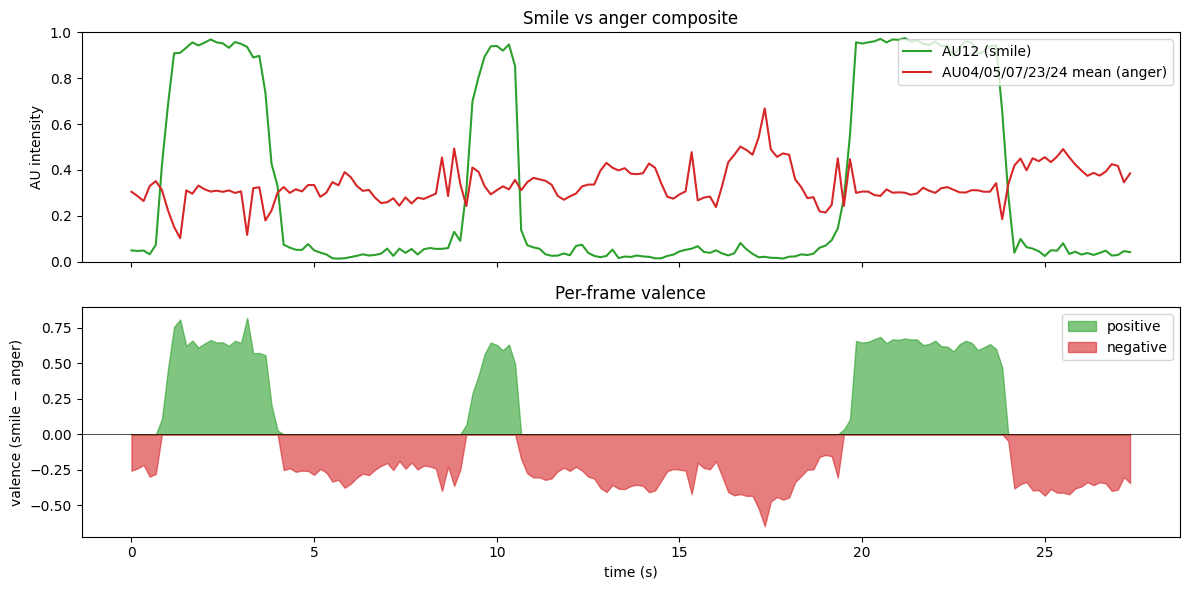

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(au["timestamp"], au["smile"], color="tab:green", label="AU12 (smile)")
axes[0].plot(au["timestamp"], au["anger_composite"], color="tab:red", label="AU04/05/07/23/24 mean (anger)")
axes[0].set_ylabel("AU intensity")
axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper right")
axes[0].set_title("Smile vs anger composite")

axes[1].fill_between(au["timestamp"], 0, au["valence"].clip(lower=0), color="tab:green", alpha=0.6, label="positive")
axes[1].fill_between(au["timestamp"], 0, au["valence"].clip(upper=0), color="tab:red", alpha=0.6, label="negative")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("valence (smile − anger)")
axes[1].legend(loc="upper right")
axes[1].set_title("Per-frame valence")

plt.tight_layout()
plt.show()


## 4. Summary numbers

In [17]:
total_s = len(au) * frame_duration_s
positive_s = (au["valence"] > 0).sum() * frame_duration_s
negative_s = (au["valence"] < 0).sum() * frame_duration_s

stats = pd.Series({
    "duration_s": round(total_s, 2),
    "mean_valence": round(au["valence"].mean(), 3),
    "mean_smile": round(au["smile"].mean(), 3),
    "mean_anger": round(au["anger_composite"].mean(), 3),
    "time_positive_s": round(positive_s, 2),
    "time_negative_s": round(negative_s, 2),
    "pct_positive": round(100 * positive_s / total_s, 1) if total_s else 0.0,
    "pct_negative": round(100 * negative_s / total_s, 1) if total_s else 0.0,
})
stats

duration_s         27.500
mean_valence       -0.015
mean_smile          0.323
mean_anger          0.337
time_positive_s     9.330
time_negative_s    18.170
pct_positive       33.900
pct_negative       66.100
dtype: float64

## 5. Save per-frame valence for reuse

Writes a small parquet keyed by `frame` so downstream metric notebooks can join in the valence signal without recomputing.

In [18]:
out = au[["frame", "timestamp", "smile", "anger_composite", "valence"]].copy()
out.to_parquet(VALENCE_OUT, index=False)
print(f"Saved: {VALENCE_OUT}  ({len(out)} rows)")

Saved: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_valence.parquet  (165 rows)
